# 03 · Shadow Prices — the output prediction cannot give

When a solver finds the optimum it also returns, for **every constraint**, a number
that says how much the objective would improve if that constraint were relaxed by
one unit. That number is the **shadow price** (or dual value), and together the
shadow prices are a **bottleneck map**: which resource is binding, and what one more
unit of it is worth.

No predictive model produces anything like it. This is often the most valuable thing
optimization gives you — it tells you not just *what to do* but *which bottleneck to
invest in and what it is worth.*

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from src.datasets.scenarios import product_mix_scenario
from src.evaluation.sensitivity import finite_difference_shadow_prices, objective_vs_rhs
from src.exporters import save_fig, save_json
from src.models import product_mix
from src.solvers.backends import solve
from src.visualisation import plot_shadow_prices

scenario = product_mix_scenario()
lp = product_mix.build(scenario)
solution = solve(lp, backend="scipy")
print(solution.summary())

status      : optimal
backend     : scipy
objective   : 36
solve_time  : 2.79 ms
solution    : doors=2, windows=6
shadow      : plant1=0, plant2=1.5, plant3=1


## Read the bottleneck map

- **plant1** has *slack* — the optimal plan does not use all of it, so one more hour
  is worth **0**. Buying more would earn nothing.
- **plant2** is *binding* and worth **1.5** per hour.
- **plant3** is *binding* and worth **1.0** per hour.

A red bar is a binding constraint; a pale bar has slack.

In [2]:
solution.shadow_price_frame()

,constraint,shadow_price,slack,binding
0,plant1,0.0,2.0,False
1,plant2,1.5,0.0,True
2,plant3,1.0,0.0,True


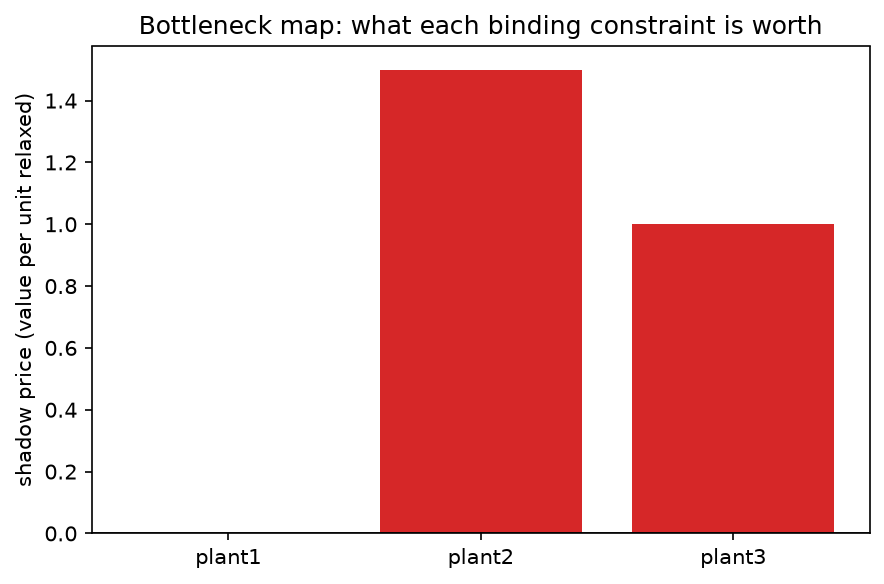

In [3]:
fig = plot_shadow_prices(solution)
path = save_fig(fig, "03_bottleneck_map")
plt.close(fig)
Image(str(path))

## Prove the shadow prices are real — re-solve and measure

A shadow price is a derivative: *change in optimum per unit of right-hand side.* We
check each one the honest way — nudge that constraint's limit by a tiny epsilon,
re-solve, and divide the change in profit by epsilon. The re-solve must reproduce
the dual the solver reported.

In [4]:
reported = solution.shadow_prices
finite_diff = finite_difference_shadow_prices(lp, backend="scipy", eps=1e-4)

print(f"{'constraint':<10}{'reported':>12}{'re-solve':>12}{'known':>10}")
for name in scenario.resources:
    print(f"{name:<10}{reported[name]:>12.4f}{finite_diff[name]:>12.4f}"
          f"{scenario.shadow_prices[name]:>10.4f}")

for name in scenario.resources:
    assert abs(reported[name] - finite_diff[name]) < 1e-3
    assert abs(reported[name] - scenario.shadow_prices[name]) < 1e-5
print("\nverified: reported duals match both the re-solve and the known values")

constraint    reported    re-solve     known
plant1          0.0000      0.0000    0.0000
plant2          1.5000      1.5000    1.5000
plant3          1.0000      1.0000    1.0000

verified: reported duals match both the re-solve and the known values


In [5]:
save_json(
    {
        "shadow_prices_reported": reported,
        "shadow_prices_finite_difference": finite_diff,
        "shadow_prices_known": scenario.shadow_prices,
        "slack": solution.slack,
        "binding_constraints": solution.binding_constraints(),
        "verified": True,
    },
    "03_shadow_prices",
)

PosixPath('/workspaces/optimization_101/outputs/data/03_shadow_prices.json')

## See the slope: profit as a bottleneck's limit grows

Sweep plant 2's hour limit and re-solve at each value. The optimal profit is a
piecewise-linear curve, and its slope **is** the shadow price: around the current
limit of 12 hours, each extra hour is worth 1.5 — until the slope changes when a
different constraint takes over as the bottleneck.

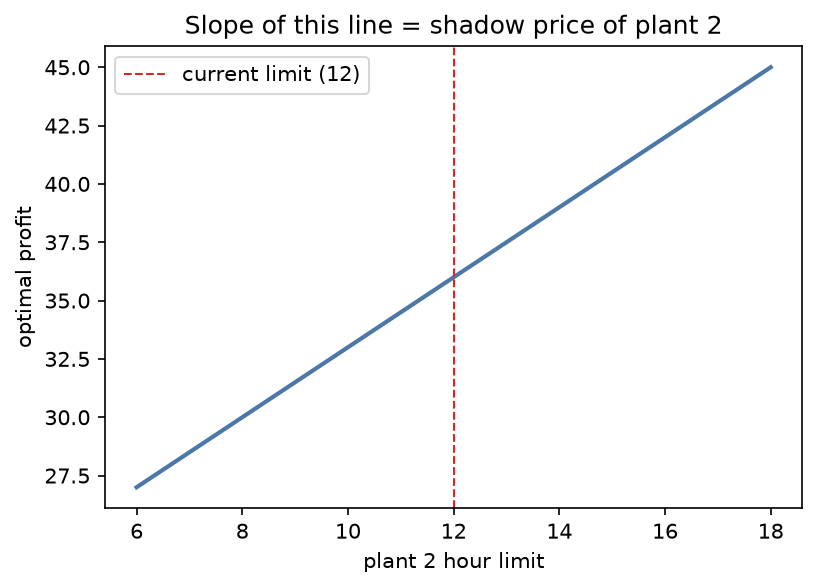

In [6]:
caps = np.linspace(6, 18, 25)
profits = objective_vs_rhs(lp, "plant2", list(caps), backend="scipy")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(caps, profits, color="#4c78a8", linewidth=2)
ax.axvline(12, color="#d62728", linestyle="--", linewidth=1, label="current limit (12)")
ax.set_xlabel("plant 2 hour limit")
ax.set_ylabel("optimal profit")
ax.set_title("Slope of this line = shadow price of plant 2")
ax.legend()
path = save_fig(fig, "03_objective_vs_capacity")
plt.close(fig)
Image(str(path))

## The strategic payoff

You can now answer *"where is my bottleneck and what is it worth?"* — plant 2 first
(1.5/hour), then plant 3 (1.0/hour), while plant 1 has room to spare. That is the
investment signal a forecast will never give you.

In **notebook 04** we cross the line from linear to **integer** decisions, where
"half a factory" is nonsense and the solver has to search.